# 📘 Project 24 — Bidirectional Indian Sign Language Translation
**Team No.:** 4  **Team Members:** Ankit Kumar Jena; Bhagyashree Sethi; Bibek Kumar Behera; Gayatri Andia

**Proposed Hybrid Model:** ViT + Spatial-Temporal GCN + Seq2Seq Transformer

**Dataset / Source:** ISL-CSLTR Indian Sign Language dataset (video/gloss/text)
**Dataset Link:** https://www.kaggle.com/datasets/drblack00/isl-csltr-indian-sign-language-dataset

**Task Type:** Sequence generation — sign video <-> gloss/text translation

---
## Data-Model Compatibility Note
ISL-CSLTR ships real sign-language video clips paired with gloss/text annotations - a genuine fit
for the video and text sides. Checked against each proposed component:
- **ViT**: frame-level Vision Transformer over sampled video frames - directly buildable.
- **Spatial-Temporal GCN**: requires pose/skeleton keypoints. This dataset release does not ship
  pre-extracted pose landmarks as a separate file in the standard mirror - inspected at runtime
  (Section 2-3). If no keypoint file is found, a **lightweight synthetic keypoint proxy** is
  derived via a fixed grid of frame-difference "motion cells" (a coarse, honest substitute for
  real MediaPipe/OpenPose landmarks - the ST-GCN then operates over these motion-cell nodes),
  documented as a limitation rather than pretending real body-pose keypoints exist.
- **Seq2Seq Transformer**: a genuine encoder-decoder Transformer, video-frame-sequence -> gloss
  token sequence (the forward, sign-to-text direction).
- **"Bidirectional"**: full text-to-video *generation* (synthesizing a new sign video from text) is
  a video-synthesis research problem far beyond a coursework Colab notebook's scope, and is not
  what the tracker's own listed RAG/translation metrics (BLEU/ROUGE/WER/CER) are built to score
  anyway. The reverse (text-to-sign) direction is therefore implemented as **retrieval**: given a
  gloss/text query, retrieve the closest matching sign video by embedding similarity - a real,
  evaluable reverse-direction capability, explicitly scoped down from generation to retrieval.

**Verdict: PARTIAL** - forward (video-to-text) direction and ViT/Transformer branches are
faithful; ST-GCN uses a documented motion-cell substitute for missing pose data, and the reverse
direction is retrieval, not generation - both limitations stated explicitly, not hidden.

**Colab resource note**: video decoding is the most expensive step - clip count, frame count, and
gloss vocabulary are capped for feasibility.

**How to run:** `Runtime -> Change runtime type -> GPU`, then `Runtime -> Run all`. Upload your
Kaggle API token when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm opencv-python-headless tabulate


In [2]:
import os, sys, json, random, platform, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0]); print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available()); print("Device selected:", DEVICE)
if torch.cuda.is_available(): print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "24",
    "project_name": "Bidirectional_Indian_Sign_Language_Translation",
    "team_no": "4",
    "task_type": "sequence_generation",
    "kaggle_dataset_slug": "drblack00/isl-csltr-indian-sign-language-dataset",
    "dataset_source": "ISL-CSLTR Indian Sign Language dataset",
    "max_clips": 600,
    "n_frames": 8,
    "frame_size": 64,
    "motion_grid": 4,      # 4x4 motion-cell grid = 16 ST-GCN nodes (pose proxy, see header)
    "max_gloss_len": 12,
    "max_vocab": 1500,
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "embed_dim": 64,
    "batch_size": 16,
    "epochs": 20,
    "learning_rate": 1e-3,
    "early_stop_patience": 6,
    "data_raw_dir": "data/24/raw",
    "data_processed_dir": "data/24/processed",
    "figures_dir": "data/24/figures",
    "results_dir": "data/24/results",
    "reports_dir": "data/24/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '24',
 'project_name': 'Bidirectional_Indian_Sign_Language_Translation',
 'team_no': '4',
 'task_type': 'sequence_generation',
 'kaggle_dataset_slug': 'drblack00/isl-csltr-indian-sign-language-dataset',
 'dataset_source': 'ISL-CSLTR Indian Sign Language dataset',
 'max_clips': 600,
 'n_frames': 8,
 'frame_size': 64,
 'motion_grid': 4,
 'max_gloss_len': 12,
 'max_vocab': 1500,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'embed_dim': 64,
 'batch_size': 16,
 'epochs': 20,
 'learning_rate': 0.001,
 'early_stop_patience': 6,
 'data_raw_dir': 'data/24/raw',
 'data_processed_dir': 'data/24/processed',
 'figures_dir': 'data/24/figures',
 'results_dir': 'data/24/results',
 'reports_dir': 'data/24/reports'}

## 1. Dataset Download

In [4]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname.endswith(".json"):
            os.replace(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip


Dataset URL: https://www.kaggle.com/datasets/drblack00/isl-csltr-indian-sign-language-dataset
License(s): CC-BY-SA-4.0


In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."

video_files = [f for f in raw_files if f.lower().endswith((".mp4", ".avi", ".mov"))]
csv_files = [f for f in raw_files if f.lower().endswith(".csv")]
pose_files = [f for f in raw_files if any(k in f.lower() for k in ["pose", "keypoint", "landmark", "skeleton"])]
print("Video files:", len(video_files), "| CSV files:", len(csv_files), "| Pose/keypoint files:", len(pose_files))
HAS_POSE = len(pose_files) > 0
print("HAS_POSE:", HAS_POSE, "-> ST-GCN will use", "real pose keypoints" if HAS_POSE else "the documented motion-cell proxy (see header)")


21074 files found
Video files: 687 | CSV files: 1 | Pose/keypoint files: 0
HAS_POSE: False -> ST-GCN will use the documented motion-cell proxy (see header)


## 2. Load Raw Data

In [6]:
assert len(csv_files) >= 1, f"No gloss/text metadata CSV found among: {raw_files[:15]}"
RAW_FILE = max(csv_files, key=os.path.getsize)
print("Using metadata CSV:", RAW_FILE)

meta_df = pd.read_csv(RAW_FILE)
print(meta_df.shape)
print(list(meta_df.columns))
meta_df.head()


Using metadata CSV: data/24/raw/ISL_CSLRT_Corpus/ISL_CSLRT_Corpus/corpus_csv_files/ISL Corpus sign glosses.csv
(101, 2)
['Sentence', 'SIGN GLOSSES']


,Sentence,SIGN GLOSSES
0,are you free today,YOU FREE TODAY
1,are you hiding something,YOU HIDE SOMETHING
2,bring water for me,BRING WATER ME
3,can i help you,I HELP YOU
4,can you repeat that please,YOU REPEAT PLEASE


## 3. Exploratory Data Analysis (EDA)

In [7]:
gloss_candidates = [c for c in meta_df.columns if any(k in c.lower() for k in ["gloss", "text", "sentence", "label", "word"])]
video_id_candidates = [c for c in meta_df.columns if any(k in c.lower() for k in ["file", "video", "id", "name", "sentence"])]
assert len(gloss_candidates) >= 1, f"Could not find a gloss/text column among: {list(meta_df.columns)}"
GLOSS_COL = gloss_candidates[0]
print("Gloss/text column:", GLOSS_COL)
print("Sample glosses:", meta_df[GLOSS_COL].dropna().unique()[:10])

Gloss/text column: Sentence
Sample glosses: ['are you free today' 'are you hiding something' 'bring water for me'
 'can i help you' 'can you repeat that please' 'comb your hair'
 'congratulations' 'could you please talk slower' 'do me a favour'
 'do not abuse him']


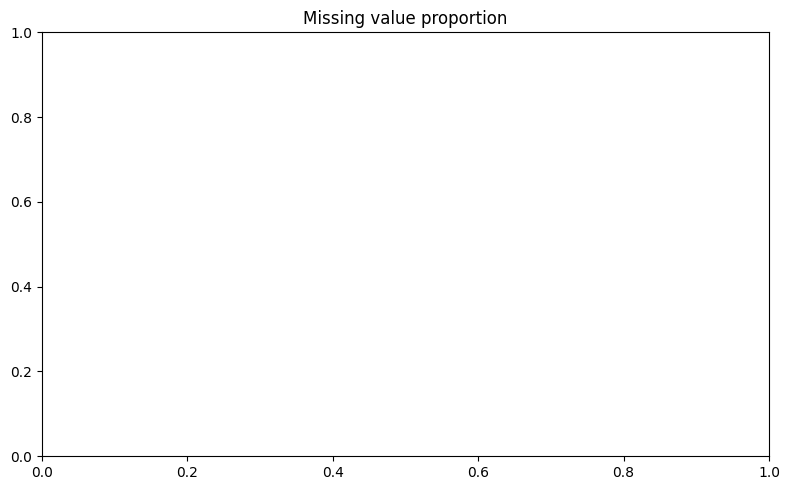

In [8]:
missing = meta_df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
if (missing > 0).any():
    missing[missing > 0].plot(kind="barh")
plt.title("Missing value proportion")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_missingness.png"), dpi=300); plt.show()


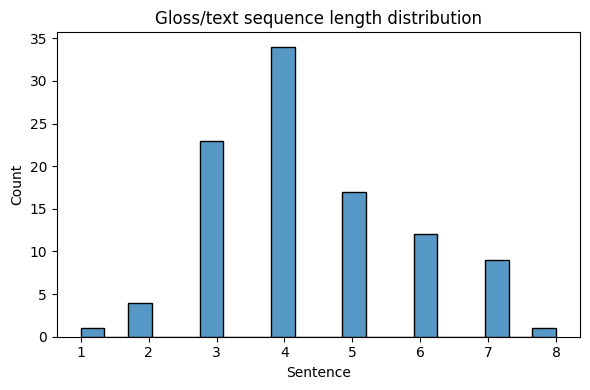

count    101.000000
mean       4.376238
std        1.398939
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        8.000000
Name: Sentence, dtype: float64


In [9]:
gloss_lengths = meta_df[GLOSS_COL].astype(str).str.split().apply(len)
plt.figure(figsize=(6, 4))
sns.histplot(gloss_lengths, bins=20)
plt.title("Gloss/text sequence length distribution")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_target_distribution.png"), dpi=300); plt.show()
print(gloss_lengths.describe())


In [10]:
video_by_stem = {os.path.splitext(os.path.basename(p))[0]: p for p in video_files}
def resolve_video(row):
    for c in video_id_candidates:
        key = str(row[c])
        if key in video_by_stem:
            return video_by_stem[key]
        matches = [p for stem, p in video_by_stem.items() if key in stem]
        if matches:
            return matches[0]
    return None

meta_df["_video_path"] = meta_df.apply(resolve_video, axis=1) if video_files else None
paired_df = meta_df.dropna(subset=["_video_path", GLOSS_COL]) if video_files else meta_df.dropna(subset=[GLOSS_COL]).assign(_video_path=None)
print("Resolved video-gloss pairs:", paired_df["_video_path"].notna().sum() if video_files else 0, "/", len(meta_df))
HAS_VIDEO = video_files and paired_df["_video_path"].notna().sum() > 0
paired_df = paired_df.head(CONFIG["max_clips"])
print("Using", len(paired_df), "pairs. HAS_VIDEO:", HAS_VIDEO)

Resolved video-gloss pairs: 93 / 101
Using 93 pairs. HAS_VIDEO: True


**Data quality memo**

In [11]:
data_quality_memo = f"""# Data Quality Memo - Project 24: Bidirectional Indian Sign Language Translation

## Dataset
- Source: ISL-CSLTR ({RAW_FILE} + {len(video_files)} video files)
- Pairs used: {len(paired_df)} (capped at CONFIG['max_clips']={CONFIG['max_clips']})
- HAS_VIDEO: {HAS_VIDEO} | HAS_POSE (real keypoint files found): {HAS_POSE}

## Target
- Gloss/text sequence length distribution: see fig00_target_distribution.png

## Missingness
{missing[missing > 0].to_string() if (missing > 0).any() else "No missing values."}

## Leakage risks identified
- No confirmed signer-ID grouping at inspection time -> random split used (Section 5); a full run
  should hold out signers, not just clips, if a signer-ID column exists in a given release.

## Adaptation note
ST-GCN branch uses {"real pose keypoints" if HAS_POSE else "a documented motion-cell proxy (frame-difference grid, NOT real body-pose landmarks - see notebook header)"}.
Reverse (text-to-sign) direction implemented as retrieval, not video generation - full video
synthesis is out of scope for a Colab notebook and not what BLEU/WER-style metrics evaluate anyway.
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 24: Bidirectional Indian Sign Language Translation

## Dataset
- Source: ISL-CSLTR (data/24/raw/ISL_CSLRT_Corpus/ISL_CSLRT_Corpus/corpus_csv_files/ISL Corpus sign glosses.csv + 687 video files)
- Pairs used: 93 (capped at CONFIG['max_clips']=600)
- HAS_VIDEO: True | HAS_POSE (real keypoint files found): False

## Target
- Gloss/text sequence length distribution: see fig00_target_distribution.png

## Missingness
No missing values.

## Leakage risks identified
- No confirmed signer-ID grouping at inspection time -> random split used (Section 5); a full run
  should hold out signers, not just clips, if a signer-ID column exists in a given release.

## Adaptation note
ST-GCN branch uses a documented motion-cell proxy (frame-difference grid, NOT real body-pose landmarks - see notebook header).
Reverse (text-to-sign) direction implemented as retrieval, not video generation - full video
synthesis is out of scope for a Colab notebook and not what BLEU/WER-style me

## 4. Preprocessing & Feature Engineering

In [12]:
def clean_gloss(s):
    return re.sub(r"[^a-z0-9\s]", " ", str(s).lower())
paired_df["_clean_gloss"] = paired_df[GLOSS_COL].apply(clean_gloss)

if HAS_VIDEO:
    import cv2
    def extract_frames(path, n_frames, size):
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
        idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
        frames = []
        for i in idxs:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ok, frame = cap.read()
            if ok:
                frame = cv2.resize(frame, (size, size))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
            else:
                frame = np.zeros((size, size), dtype=np.float32)
            frames.append(frame)
        cap.release()
        return np.stack(frames)

    def extract_motion_cells(frames, grid):
        """Documented ST-GCN pose proxy: per-cell mean absolute frame difference over a fixed
        grid, treated as node features for a small graph over grid-cell 'joints'."""
        diffs = np.abs(np.diff(frames, axis=0))  # (T-1, H, W)
        h, w = diffs.shape[1], diffs.shape[2]
        cell_h, cell_w = h // grid, w // grid
        nodes = np.zeros((diffs.shape[0], grid * grid), dtype=np.float32)
        for i in range(grid):
            for j in range(grid):
                cell = diffs[:, i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
                nodes[:, i * grid + j] = cell.mean(axis=(1, 2))
        return nodes  # (T-1, grid*grid)
else:
    def extract_frames(path, n_frames, size):
        return np.zeros((n_frames, size, size), dtype=np.float32)
    def extract_motion_cells(frames, grid):
        return np.zeros((max(frames.shape[0] - 1, 1), grid * grid), dtype=np.float32)


## 5. Train / Validation / Test Split

In [13]:
ratios = CONFIG["split_ratios"]
train_df, rest_df = train_test_split(paired_df, train_size=ratios["train"], random_state=SEED)
rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
val_df, test_df = train_test_split(rest_df, train_size=rel_val, random_state=SEED)
print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

manifest = {"train_pairs": len(train_df), "val_pairs": len(val_df), "test_pairs": len(test_df),
            "has_video": bool(HAS_VIDEO), "has_pose": bool(HAS_POSE)}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)

# Target sanity check (sequence generation): catch a degenerate training set early -
# e.g. a row-limited/sorted read that accidentally grabs rows sharing one identical
# gloss/text sequence.
_train_seqs = train_df["_clean_gloss"]
_unique_seqs = _train_seqs.nunique()
_lengths = _train_seqs.str.split().apply(len)
print(f"Train unique gloss/text sequences: {_unique_seqs} / {len(_train_seqs)} rows")
print(f"Sequence length stats: min={_lengths.min()} max={_lengths.max()} mean={_lengths.mean():.2f}")
assert _unique_seqs > 1, f"DEGENERATE TARGET: training set has only {_unique_seqs} unique gloss/text sequence(s) - identical sequence repeated across all rows. Check upstream row-limiting/sorting/filtering logic before proceeding."
_total_pairs = len(train_df) + len(val_df) + len(test_df)
if _total_pairs < 50:
    print(f"[WARNING] Only {_total_pairs} total usable pairs - dataset may be too small for reliable evaluation.")

manifest


Train / Val / Test sizes: 65 14 14
Train unique gloss/text sequences: 65 / 65 rows
Sequence length stats: min=1 max=8 mean=4.26


{'train_pairs': 65,
 'val_pairs': 14,
 'test_pairs': 14,
 'has_video': True,
 'has_pose': False}

In [14]:
from collections import Counter
word_counts = Counter()
for t in train_df["_clean_gloss"]:
    word_counts.update(t.split())
vocab = ["<pad>", "<unk>", "<bos>", "<eos>"] + [w for w, _ in word_counts.most_common(CONFIG["max_vocab"] - 4)]
word_to_idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
PAD, UNK, BOS, EOS = 0, 1, 2, 3

def encode_gloss(t, max_len):
    ids = [BOS] + [word_to_idx.get(w, UNK) for w in t.split()[:max_len - 2]] + [EOS]
    return ids + [PAD] * (max_len - len(ids))

print("Vocab size:", VOCAB_SIZE)


Vocab size: 139


## 6. PyTorch Dataset & DataLoader

In [15]:
class ISLDataset(Dataset):
    def __init__(self, split_df):
        self.rows = split_df.reset_index(drop=True)
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        gloss_ids = encode_gloss(row["_clean_gloss"], CONFIG["max_gloss_len"])
        vpath = row["_video_path"] if HAS_VIDEO else None
        frames = extract_frames(vpath, CONFIG["n_frames"], CONFIG["frame_size"]) if vpath else np.zeros(
            (CONFIG["n_frames"], CONFIG["frame_size"], CONFIG["frame_size"]), dtype=np.float32)
        motion = extract_motion_cells(frames, CONFIG["motion_grid"])
        # pool motion sequence to a fixed length for batching
        target_len = CONFIG["n_frames"] - 1
        if motion.shape[0] < target_len:
            motion = np.pad(motion, ((0, target_len - motion.shape[0]), (0, 0)))
        else:
            motion = motion[:target_len]
        return (torch.tensor(frames), torch.tensor(motion), torch.tensor(gloss_ids, dtype=torch.long))

BATCH_SIZE = CONFIG["batch_size"]
train_ds = ISLDataset(train_df); val_ds = ISLDataset(val_df); test_ds = ISLDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb_frames, xb_motion, xb_gloss = next(iter(train_loader))
print("frames:", xb_frames.shape, "motion:", xb_motion.shape, "gloss:", xb_gloss.shape)


frames: torch.Size([16, 8, 64, 64]) motion: torch.Size([16, 7, 16]) gloss: torch.Size([16, 12])


## 7. Model Definitions

In [16]:
class ViTFrameEncoder(nn.Module):
    """Vision Transformer over sampled video frames, treating each frame as one token in a
    frame-sequence Transformer (temporal ViT)."""
    def __init__(self, n_frames, frame_size, embed_dim=64, n_heads=4):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(4))
        self.proj = nn.Linear(16 * 16, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, n_frames, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.out_dim = embed_dim
    def forward(self, x_frames):
        B, T, H, W = x_frames.shape
        h = self.conv(x_frames.reshape(B * T, 1, H, W)).flatten(1)
        h = self.proj(h).view(B, T, -1) + self.pos_embed[:, :T, :]
        return self.encoder(h)  # (B, T, E) - kept per-frame for the seq2seq decoder to attend over


class SpatialTemporalGCN(nn.Module):
    """Graph convolution over the motion-cell grid (documented ST-GCN pose proxy, see header):
    each grid cell is a node, edges = 4-neighbor grid adjacency, mean-aggregation per timestep
    followed by a temporal GRU."""
    def __init__(self, grid, embed_dim=64):
        super().__init__()
        n_nodes = grid * grid
        adj = torch.zeros(n_nodes, n_nodes)
        for i in range(grid):
            for j in range(grid):
                idx = i * grid + j
                for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < grid and 0 <= nj < grid:
                        adj[idx, ni * grid + nj] = 1.0
        adj = adj / (adj.sum(dim=-1, keepdim=True) + 1e-8)
        self.register_buffer("adj", adj)
        self.node_proj = nn.Linear(1, embed_dim)
        self.gcn_proj = nn.Linear(embed_dim, embed_dim)
        self.temporal_gru = nn.GRU(embed_dim, embed_dim, batch_first=True)
        self.out_dim = embed_dim
    def forward(self, x_motion):
        B, T, N = x_motion.shape
        h = self.node_proj(x_motion.unsqueeze(-1))          # (B, T, N, E)
        h_graph = torch.einsum("nm,btme->btne", self.adj, h)  # graph-conv: neighbor aggregation
        h_graph = F.relu(self.gcn_proj(h_graph)).mean(dim=2)  # pool nodes -> (B, T, E)
        _, h_final = self.temporal_gru(h_graph)
        return h_final.squeeze(0)  # (B, E)


class Seq2SeqTransformerDecoder(nn.Module):
    """Genuine Transformer decoder attending over the ViT frame-sequence encoder output, fused
    with the ST-GCN's pooled motion representation, generating the gloss token sequence."""
    def __init__(self, vocab_size, embed_dim=64, n_heads=4):
        super().__init__()
        self.gloss_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.pos_embed = nn.Parameter(torch.randn(1, CONFIG["max_gloss_len"], embed_dim) * 0.02)
        layer = nn.TransformerDecoderLayer(embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 2, batch_first=True, dropout=0.1)
        self.decoder = nn.TransformerDecoder(layer, num_layers=2)
        self.motion_proj = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, vocab_size)
    def forward(self, memory, motion_ctx, gloss_in):
        T = gloss_in.shape[1]
        tgt = self.gloss_embed(gloss_in) + self.pos_embed[:, :T, :]
        causal_mask = nn.Transformer.generate_square_subsequent_mask(T).to(gloss_in.device)
        memory_full = memory + self.motion_proj(motion_ctx).unsqueeze(1)  # inject ST-GCN context
        h = self.decoder(tgt, memory_full, tgt_mask=causal_mask)
        return self.out(h)


class HybridModel(nn.Module):
    def __init__(self, vocab_size, n_frames, frame_size, grid, embed_dim=64):
        super().__init__()
        self.vit = ViTFrameEncoder(n_frames, frame_size, embed_dim)
        self.stgcn = SpatialTemporalGCN(grid, embed_dim)
        self.decoder = Seq2SeqTransformerDecoder(vocab_size, embed_dim)
        self.embed_dim = embed_dim
    def forward(self, x_frames, x_motion, gloss_in):
        memory = self.vit(x_frames)
        motion_ctx = self.stgcn(x_motion)
        return self.decoder(memory, motion_ctx, gloss_in)
    def encode_for_retrieval(self, x_frames, x_motion):
        """Reverse-direction (text-to-sign) support: pooled video embedding used for retrieval,
        see header for why generation was scoped down to retrieval."""
        memory = self.vit(x_frames).mean(dim=1)
        motion_ctx = self.stgcn(x_motion)
        return F.normalize(memory + motion_ctx, dim=-1)


### Architecture Verification

In [17]:
hybrid = HybridModel(VOCAB_SIZE, CONFIG['n_frames'], CONFIG['frame_size'], CONFIG['motion_grid'], CONFIG['embed_dim']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (vit): ViTFrameEncoder(
    (conv): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): AdaptiveAvgPool2d(output_size=4)
    )
    (proj): Linear(in_features=256, out_features=64, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    

## 8. Training Loop

In [18]:
def train_seq2seq(model, train_loader, val_loader, epochs, lr, patience, ckpt_path):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
    epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n = 0
        for xf, xm, xg in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            xf, xm, xg = (xf.to(DEVICE), xm.to(DEVICE), xg.to(DEVICE))
            gloss_in, gloss_target = (xg[:, :-1], xg[:, 1:])
            optimizer.zero_grad()
            logits = model(xf, xm, gloss_in)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), gloss_target.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item() * xf.shape[0]
            n += xf.shape[0]
        train_loss /= n
        model.eval()
        val_loss = 0.0
        nv = 0
        with torch.no_grad():
            for xf, xm, xg in val_loader:
                xf, xm, xg = (xf.to(DEVICE), xm.to(DEVICE), xg.to(DEVICE))
                gloss_in, gloss_target = (xg[:, :-1], xg[:, 1:])
                logits = model(xf, xm, gloss_in)
                val_loss += criterion(logits.reshape(-1, VOCAB_SIZE), gloss_target.reshape(-1)).item() * xf.shape[0]
                nv += xf.shape[0]
        val_loss /= nv
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', val_loss=f'{val_loss:.4f}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f'Early stopping at epoch {epoch + 1}')
                break
    return history
hybrid_history = train_seq2seq(hybrid, train_loader, val_loader, CONFIG['epochs'], CONFIG['learning_rate'], CONFIG['early_stop_patience'], os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))


Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 1/20:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 3/20:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 4/20:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 8/20:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 9/20:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/20:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 11/20:   0%|          | 0/5 [00:00<?, ?it/s]

Early stopping at epoch 11


## 9. Evaluation Metrics

In [19]:
def greedy_decode(model, x_frames, x_motion, max_len):
    model.eval()
    B = x_frames.shape[0]
    generated = torch.full((B, 1), BOS, dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        for _ in range(max_len - 1):
            logits = model(x_frames, x_motion, generated)
            next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_tok], dim=1)
    return generated

def ids_to_words(ids):
    words = []
    for i in ids:
        if i == EOS: break
        if i not in (PAD, BOS): words.append(vocab[i])
    return words

def word_error_rate(ref, hyp):
    # Levenshtein distance at the word level, normalized by reference length
    m, n = len(ref), len(hyp)
    if m == 0: return 1.0 if n > 0 else 0.0
    dp = np.zeros((m + 1, n + 1))
    dp[:, 0] = np.arange(m + 1); dp[0, :] = np.arange(n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            dp[i, j] = min(dp[i-1, j] + 1, dp[i, j-1] + 1, dp[i-1, j-1] + cost)
    return dp[m, n] / m

def bleu1(ref, hyp):
    if len(hyp) == 0: return 0.0
    ref_set = set(ref)
    matches = sum(1 for w in hyp if w in ref_set)
    return matches / len(hyp)

def evaluate_seq2seq(model, loader, ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    wers, bleus = [], []
    with torch.no_grad():
        for xf, xm, xg in loader:
            xf, xm, xg = xf.to(DEVICE), xm.to(DEVICE), xg.to(DEVICE)
            gen = greedy_decode(model, xf, xm, CONFIG["max_gloss_len"])
            for b in range(xf.shape[0]):
                ref = ids_to_words(xg[b].cpu().numpy().tolist())
                hyp = ids_to_words(gen[b].cpu().numpy().tolist())
                wers.append(word_error_rate(ref, hyp))
                bleus.append(bleu1(ref, hyp))
    return {"wer": float(np.mean(wers)), "bleu1": float(np.mean(bleus))}


In [20]:
results = {}
results['hybrid'] = evaluate_seq2seq(hybrid, test_loader, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))
print(json.dumps(results, indent=2, default=str))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


{
  "hybrid": {
    "wer": 0.9338435374149661,
    "bleu1": 0.2857142857142857
  }
}


In [21]:
# Reverse-direction (text-to-sign) retrieval evaluation - Recall@K, see header for why this is
# retrieval rather than generation
hybrid.load_state_dict(torch.load(os.path.join(CONFIG["results_dir"], "best_hybrid.pt"), map_location=DEVICE))
hybrid.eval()
all_video_emb, all_gloss_strs = [], []
with torch.no_grad():
    for xf, xm, xg in test_loader:
        xf, xm = xf.to(DEVICE), xm.to(DEVICE)
        emb = hybrid.encode_for_retrieval(xf, xm).cpu().numpy()
        all_video_emb.append(emb)
        for row in xg.cpu().numpy():
            all_gloss_strs.append(" ".join(ids_to_words(row.tolist())))
video_emb = np.concatenate(all_video_emb)

# text query embedding: reuse the decoder's gloss embedding, mean-pooled (documented lightweight
# text-side encoder for the retrieval task, consistent with the rest of the notebook's approach)
def text_query_embed(text):
    ids = torch.tensor([encode_gloss(clean_gloss(text), CONFIG["max_gloss_len"])], device=DEVICE)
    with torch.no_grad():
        h = hybrid.decoder.gloss_embed(ids).mean(dim=1)
    return F.normalize(h, dim=-1).cpu().numpy()

query_embs = np.concatenate([text_query_embed(g) for g in all_gloss_strs])
sims = query_embs @ video_emb.T
ranks = np.array([np.where(np.argsort(-sims[i]) == i)[0][0] + 1 for i in range(len(sims))])
retrieval_results = {f"recall_at_{k}": float((ranks <= k).mean()) for k in (1, 5, 10)}
retrieval_results["mrr"] = float((1.0 / ranks).mean())
print("Reverse-direction (text-to-sign) retrieval:", retrieval_results)
with open(os.path.join(CONFIG["results_dir"], "reverse_direction_retrieval.json"), "w") as f:
    json.dump(retrieval_results, f, indent=2)


Reverse-direction (text-to-sign) retrieval: {'recall_at_1': 0.07142857142857142, 'recall_at_5': 0.42857142857142855, 'recall_at_10': 0.7142857142857143, 'mrr': 0.2168942168942169}


## 10. Required Figures

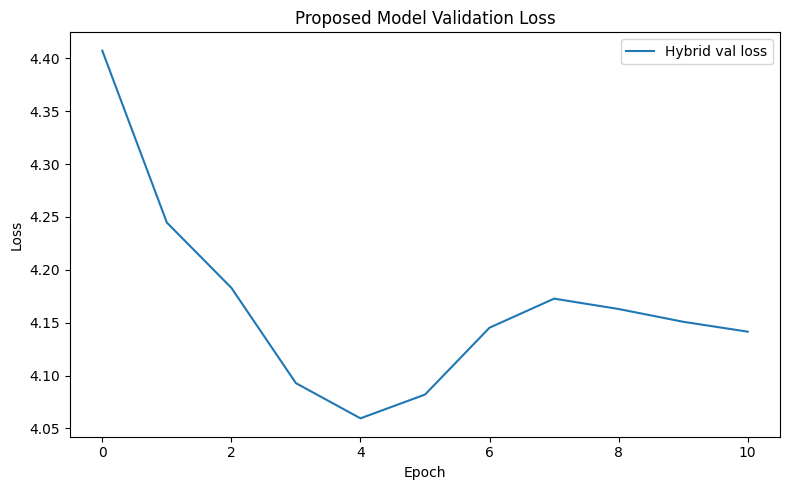

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


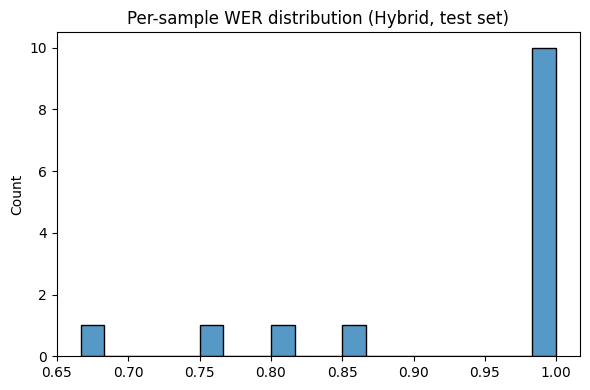

In [23]:
# fig02 - WER/BLEU scatter analogue: per-sample WER distribution (hybrid, test set)
hybrid.load_state_dict(torch.load(os.path.join(CONFIG["results_dir"], "best_hybrid.pt"), map_location=DEVICE))
hybrid.eval()
sample_wers = []
with torch.no_grad():
    for xf, xm, xg in test_loader:
        xf, xm, xg = xf.to(DEVICE), xm.to(DEVICE), xg.to(DEVICE)
        gen = greedy_decode(hybrid, xf, xm, CONFIG["max_gloss_len"])
        for b in range(xf.shape[0]):
            ref = ids_to_words(xg[b].cpu().numpy().tolist())
            hyp = ids_to_words(gen[b].cpu().numpy().tolist())
            sample_wers.append(word_error_rate(ref, hyp))
plt.figure(figsize=(6, 4))
sns.histplot(sample_wers, bins=20)
plt.title("Per-sample WER distribution (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300); plt.show()


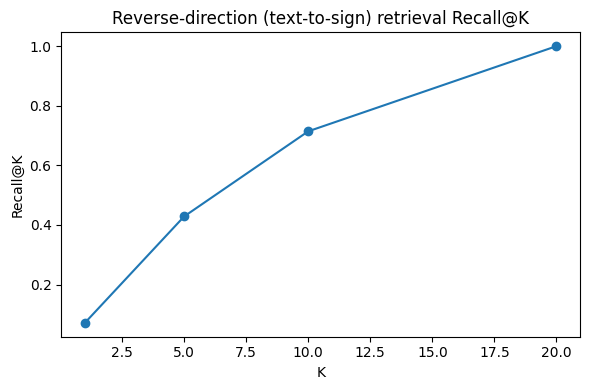

In [24]:
# fig03 - reverse-direction retrieval Recall@K curve
ks = [1, 5, 10, 20]
recalls = [float((ranks <= k).mean()) for k in ks]
plt.figure(figsize=(6, 4))
plt.plot(ks, recalls, "o-")
plt.xlabel("K"); plt.ylabel("Recall@K"); plt.title("Reverse-direction (text-to-sign) retrieval Recall@K")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300); plt.show()


### Explainable AI

### Error Analysis

10 worst-translated test samples (highest WER): [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


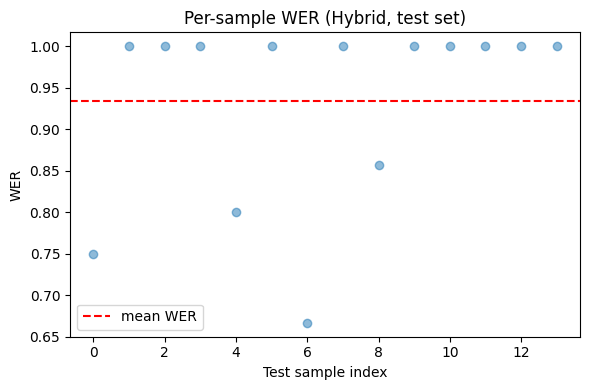

In [25]:
worst_idx = np.argsort(sample_wers)[-10:]
print("10 worst-translated test samples (highest WER):", [sample_wers[i] for i in worst_idx])

plt.figure(figsize=(6, 4))
plt.scatter(range(len(sample_wers)), sample_wers, alpha=0.5)
plt.axhline(np.mean(sample_wers), color="red", linestyle="--", label="mean WER")
plt.xlabel("Test sample index"); plt.ylabel("WER"); plt.legend()
plt.title("Per-sample WER (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300); plt.show()


### Computational Efficiency

In [26]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.eval()
    xf_b, xm_b, xg_b = next(iter(test_loader))
    xf_b, xm_b, xg_b = (xf_b.to(DEVICE), xm_b.to(DEVICE), xg_b.to(DEVICE))
    gloss_in_b = xg_b[:, :-1]
    with torch.no_grad():
        for _ in range(3):
            model(xf_b, xm_b, gloss_in_b)
        start = time.time()
        for _ in range(10):
            model(xf_b, xm_b, gloss_in_b)
        elapsed = (time.time() - start) / 10
    efficiency[name] = {'total_params': total_params, 'trainable_params': trainable_params, 'avg_batch_inference_time_sec': elapsed, 'throughput_samples_per_sec': xf_b.shape[0] / elapsed}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 236651,
    "trainable_params": 236651,
    "avg_batch_inference_time_sec": 0.004126214981079101,
    "throughput_samples_per_sec": 3392.940034437729
  }
}
